In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, spectrogram
from TIF import Info, Anotaciones, RawSignal

In [11]:
class ECGSignal(RawSignal):
    def __init__(self, data, sfreq, info=None, anotaciones=None, start_time=None, end_time=None):
        """
        Clase especializada para el análisis de señales ECG.

        Parameters:
        - data (np.ndarray): señal ECG, forma esperada (n_canales, n_muestras)
        - sfreq (float): frecuencia de muestreo
        - info (dict): información de los canales
        - anotaciones (Anotaciones): eventos asociados
        - start_time (float): tiempo de inicio en segundos
        - end_time (float): tiempo de fin en segundos
        """
        data = data if data.ndim == 2 else data[np.newaxis, :]
        super().__init__(data, sfreq, info, anotaciones)
        self.start_idx = int(start_time * sfreq) if start_time else 0
        self.end_idx = int(end_time * sfreq) if end_time else self.data.shape[1]
        self.r_peaks = []
        self.hr = 0.0

    def detectar_r_peaks(self, canal=0, height=None, distance=None):
        señal = self.data[canal, self.start_idx:self.end_idx]
        if height is None:
            height = np.mean(señal)
        if distance is None:
            distance = self.sfreq / 2.5
        peaks, _ = find_peaks(señal, height=height, distance=distance)
        self.r_peaks = peaks + self.start_idx
        return self.r_peaks

    def calcular_hr(self):
        if len(self.r_peaks) == 0:
            self.detectar_r_peaks()
        rr_intervals = np.diff(self.r_peaks) / self.sfreq
        if len(rr_intervals) == 0 or np.mean(rr_intervals) == 0:
            self.hr = 0.0
        else:
            self.hr = 60. / np.mean(rr_intervals)
        return self.hr

    def tiempo_frecuencia(self, canal=0):
        señal = self.data[canal, self.start_idx:self.end_idx]
        f, t, Sxx = spectrogram(señal, fs=self.sfreq)
        plt.pcolormesh(t, f, Sxx, shading='gouraud')
        plt.title(f"ECG Tiempo-Frecuencia - Canal {canal}")
        plt.ylabel('Frecuencia [Hz]')
        plt.xlabel('Tiempo [s]')
        plt.colorbar(label="Intensidad")
        plt.tight_layout()
        plt.show()

    def plot_r_peaks(self, canal=0):
        señal = self.data[canal, self.start_idx:self.end_idx]
        tiempo = np.arange(self.start_idx, self.end_idx) / self.sfreq
        if len(self.r_peaks) == 0:
            self.detectar_r_peaks(canal)
        picos_rel = np.array(self.r_peaks) - self.start_idx

        plt.figure(figsize=(12, 4))
        plt.plot(tiempo, señal, label="ECG")
        plt.plot(tiempo[picos_rel], señal[picos_rel], 'ro', label="Picos R")
        plt.title(f"Señal ECG con Picos R - Canal {canal}")
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Amplitud [mV]")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


In [30]:
# Cargar la señal
ecg_data = np.load(r"C:\Users\DELL\Desktop\TIF-1\2. Datos Prueba\ecg\ecg.npy")

In [31]:
ecg_data.shape

(388971,)

In [33]:
# Asegurar que tenga forma (1, n_muestras)
if ecg_data.ndim == 1:
    ecg_data = ecg_data.reshape(1, -1)

In [40]:
raw = RawSignal(data=ecg_data, sfreq=500, info=None, anotaciones=None)

# Solución clave: crear el atributo manualmente para evitar el error
raw.anotaciones = None

# Ahora podés aplicar el filtro sin que falle
raw_filtrada = raw.filter(l_freq=0.5, h_freq=40.0, notch_freq=50.0)

In [45]:
# Crear objeto ECGSignal con recorte de tiempo si querés (opcional)
ecg = ECGSignal(data=ecg_data, sfreq=500, start_time=5, end_time=15)

In [42]:
picos = ecg.detectar_r_peaks(canal=0)
print(f"Picos R detectados: {len(picos)}")

Picos R detectados: 12


In [43]:
# Calcular frecuencia cardíaca
fc = ecg.calcular_hr()
print(f"Frecuencia cardíaca promedio: {fc:.2f} bpm")

Frecuencia cardíaca promedio: 88.57 bpm


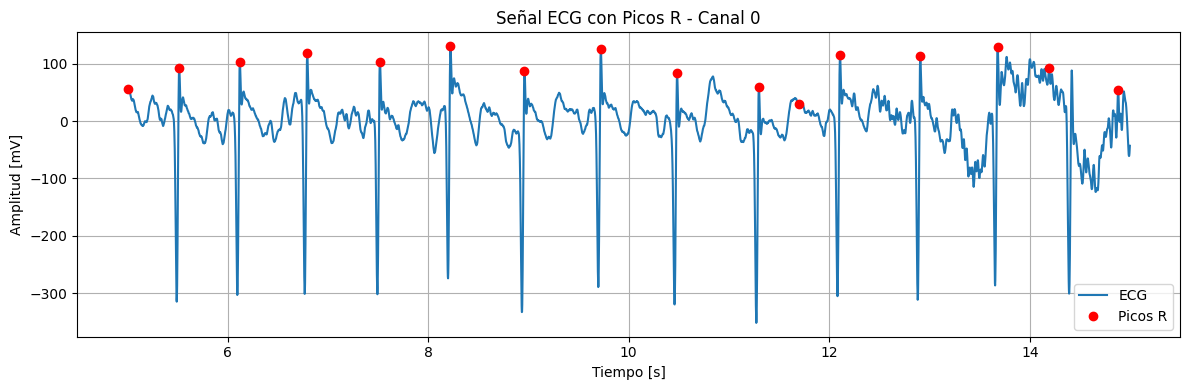

In [46]:
# Graficar la señal con picos R
ecg.plot_r_peaks(canal=0)